<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment/blob/main/ESAA_YB_WEEK12_study_0518.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ch6. 1~5 (p.399 ~ 430)

#6. 차원 축소

##6.1 차원 축소(Dimension Reduction) 개요
- 차원 축소 알고리즘: PCA, LDA, SVD, NMF
  - 이미지나 텍스트 데이터에서 숨겨진 의미와 특징을 찾아내는 데 활용됨.
- 많은 피처를 더 적은 차원으로 줄여 데이터의 복잡성과 희소성을 완화하는 방법
- 피처 수가 너무 많으면 예측 성능이 떨어지고, 변수 간 상관관계로 인한 다중공선성 문제가 발생
- 차원 축소 장점
  - 많은 피처를 줄여 데이터를 더 직관적으로 이해하고 시각화
  - 데이터 크기가 감소해 학습 속도와 처리 효율도 향상
- 두 가지로 나뉨.
  - 피처 선택: 중요한 피처만 남김.
  - 피처 추출: 기존 피처를 압축해 새로운 특성을 만듦.
    - 기존 데이터를 단순히 줄이는 것이 아니라, 데이터를 더 잘 설명하는 새로운 잠재적 특성으로 변환하는 과정

##6.2 PCA(Principal Component Analysis)


###PCA 개요
- 데이터의 분산이 가장 큰 방향을 새로운 축(주성분)으로 설정해 차원을 축소하는 방법
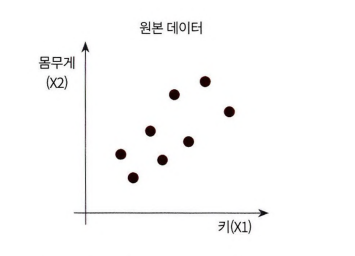
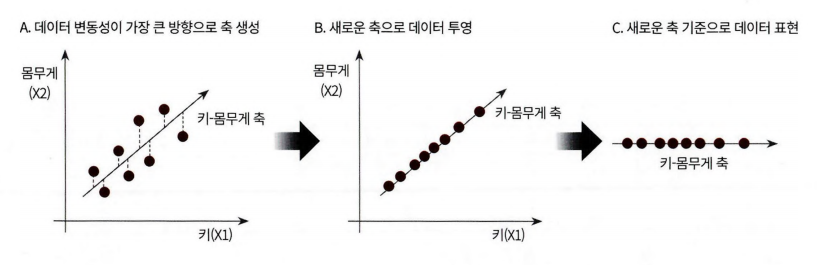
- 가장 먼저 데이터 변동성이 가장 큰 축을 만들고, 이후에는 서로 직각(직교)인 축들을 차례로 생성
- 원본 데이터를 이 새로운 축에 투영하면, 중요한 정보는 유지하면서 더 적은 차원의 데이터로 변환할 수 있음.
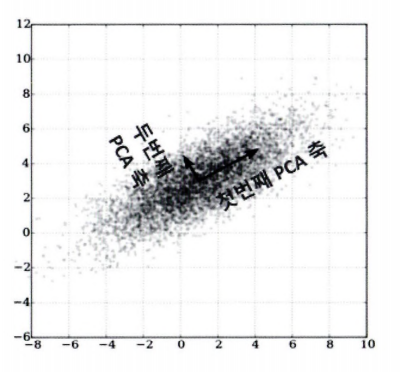

- 적은 수의 주성분만으로도 원본 데이터의 중요한 변동성을 대부분 설명
- 선형대수 관점에서
  - 데이터의 공분산 행렬을 고유값 분해해
  - 분산이 가장 큰 방향의 고유벡터(주성분)를 찾는 과정
  - 공분산: 변수들 간의 함께 변하는 정도를 의미
  - 공분산 행렬: 이러한 관계를 정리한 행렬

#### 공분산 행렬의 분해

입력 데이터의 공분산 행렬을 $C$라고 하면, 공분산 행렬의 특성으로 인해 다음과 같이 분해

$$C=P\Sigma P^T$$

* $P$: $n \times n$ 직교행렬
* $\Sigma$: $n \times n$ 정방행렬
* $P^T$: 행렬 $P$의 전치 행렬

위 식은 고유벡터 행렬과 고유값 행렬로 다음과 같이 대응

$$C=[e_1 \cdots e_n]\begin{bmatrix}\lambda_1&\cdots&0\\\vdots&\ddots&\vdots\\0&\cdots&\lambda_n\end{bmatrix}\begin{bmatrix}e_1^t\\\vdots\\e_n^t\end{bmatrix}$$

**고유벡터 직교 행렬 $\times$ 고유값 정방 행렬 $\times$ 고유벡터 직교 행렬의 전치 행렬**로 분해

* $e_i$: $i$번째 고유벡터
* $\lambda_i$: $i$번째 고유벡터의 크기(고유값)
* **고유벡터의 방향성(주성분):**
* $e_1$: 가장 분산이 큰 방향을 가진 고유벡터
* $e_2$: $e_1$에 수직이면서 다음으로 가장 분산이 큰 방향을 가진 고유벡터

**=> 입력 데이터의 공분산 행렬이 고유벡터와 고유값으로 분해될 수 있으며, 이렇게 분해된 고유벡터를 이용해 입력 데이터를 선형 변환하는 방식이 PCA**

```{b}
Steps of PCA
1) 입력 데이터 세트의 공분산 행렬을 생성
2) 공분산 행렬의 고유벡터와 고유값을 계산
3) 고유값이 가장 큰 순으로 K개(PCA 변환 차수)만큼 고유벡터를 추출
4) 고유값이 가장 큰 순으로 추출된 고유벡터를 이용해 새롭게 입력 데이터를 변환
```


####붓꽃(Iris) 데이터 세트
- 4개의 속성: sepal length, sepal width, petal length, petal width

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

iris = load_iris()
# 넘파이 데이터 세트를 판다스 DataFrame으로 변환
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
irisDF = pd.DataFrame(iris.data, columns=columns)
irisDF['target']=iris.target
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


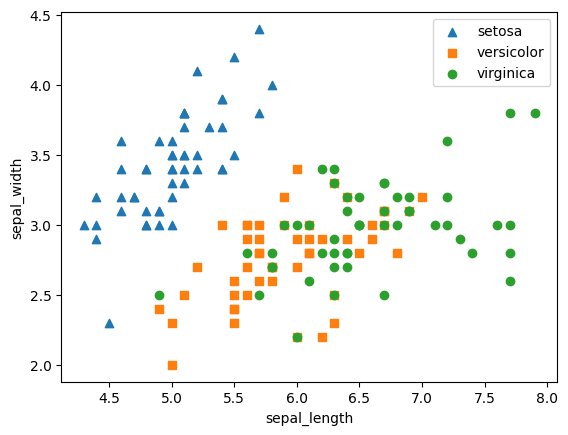

In [2]:
# setosa는 세모, versicolor는 네모, virginica는 동그라미로 표현
markers = ['^', 's', 'o']

# setosa의 target 값은 0, versicolor는 1, virginica는 2. 각 target별로 다른 모양으로 산점도로 표시
for i, marker in enumerate(markers):
  x_axis_data = irisDF[irisDF['target']==i]['sepal_length']
  y_axis_data = irisDF[irisDF['target']==i]['sepal_width']
  plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])

plt.legend()
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.show()

- 붓꽃 데이터에서 Setosa는 비교적 쉽게 구분되지만, Versicolor와 Virginica는 기존 속성만으로 구분하기 어려움.
- 이를 해결하기 위해 PCA를 사용해 4개의 속성을 2개의 주성분으로 축소하여 데이터를 2차원으로 시각화
- PCA는 속성 스케일의 영향을 받기 때문에, 적용 전에 StandardScaler로 모든 속성을 평균 0, 분산 1로 표준화해야 함.

In [3]:
from sklearn.preprocessing import StandardScaler

# Target 값을 제외한 모든 속성 값을 StandardScaler를 이용해 표준 정규 분포를 가지는 값들로 변환
iris_scaled = StandardScaler().fit_transform(irisDF.iloc[:, :-1])

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

# fit()과 transform()을 호출해 PCA 변환 데이터 반환
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)
print(iris_pca.shape)

(150, 2)


In [5]:
# PCA 변환된 데이터의 칼럼명을 각각 pca_component_1, pca_component_2로 명명
pca_columns = ['pca_component_1', 'pca_component_2']
irisDF_pca = pd.DataFrame(iris_pca, columns=pca_columns)
irisDF_pca['target'] = iris.target
irisDF_pca.head(3)

,pca_component_1,pca_component_2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0


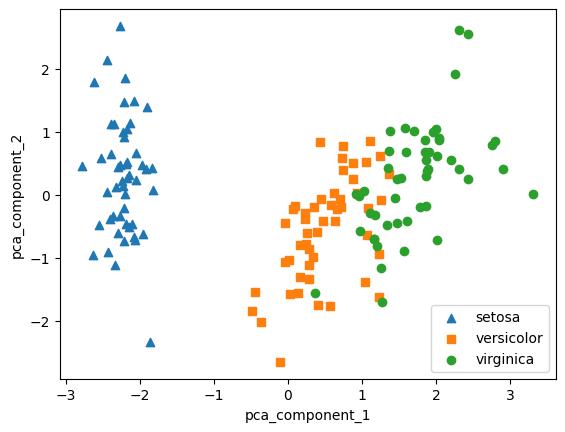

In [6]:
# setosa를 세모, versicolor를 네모, virgnica를 동그라미로 표시
markers=['^', 's', 'o']

# pca_component_1을 x축, pca_component_2를 y축으로 scatter plot 수행
for i, marker in enumerate(markers):
  x_axis_data = irisDF_pca[irisDF_pca['target']==i]['pca_component_1']
  y_axis_data = irisDF_pca[irisDF_pca['target']==i]['pca_component_2']
  plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])

plt.legend()
plt.xlabel('pca_component_1')
plt.ylabel('pca_component_2')
plt.show()

- PCA 변환 후에도 Setosa 품종은 첫 번째 주성분 축을 기준으로 뚜렷하게 구분됨.
- Versicolor와 Virginica는 일부 겹치지만 비교적 잘 분리되며, 이는 첫 번째 PCA 축이 데이터의 변동성을 잘 반영했기 때문임.
- explained_variance_ratio_ 속성: 각 PCA 컴포넌트가 전체 데이터 변동성 중 얼마나 설명하는지를 나타냄.

In [7]:
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


- 첫 번째 PCA 요소는 전체 변동성의 약 72.9%, 두 번째 요소는 약 22.8%를 설명함.

=> 2개의 PCA 요소만으로도 원본 데이터 변동성의 약 95%를 유지할 수 있음.

In [8]:
# 원본 데이터와 PCA 변환 데이터를 각각 RandomForestClassifier로 분류하여 성능을 비교함.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

rcf = RandomForestClassifier(random_state=156)
scores = cross_val_score(rcf, iris.data, iris.target, scoring='accuracy', cv=3)
print('원본 데이터 교차 검증 개별 정확도:', scores)
print('원본 데이터 평균 정확도:', np.mean(scores))

원본 데이터 교차 검증 개별 정확도: [0.98 0.94 0.96]
원본 데이터 평균 정확도: 0.96


In [9]:
pca_X = irisDF_pca[['pca_component_1', 'pca_component_2']]
scores_pca = cross_val_score(rcf, pca_X, iris.target, scoring='accuracy', cv=3)
print('PCA 변환 데이터 교차 검증 개별 정확도:', scores_pca)
print('PCA 변환 데이터 평균 정확도:', np.mean(scores_pca))

PCA 변환 데이터 교차 검증 개별 정확도: [0.88 0.88 0.88]
PCA 변환 데이터 평균 정확도: 0.88


- PCA로 차원을 줄이면 원본 데이터보다 예측 정확도가 일부 감소할 수 있음.
- 붓꽃 데이터에서는 속성이 4개에서 2개로 50% 감소했지만, 정확도는 약 8%만 하락해 데이터 특성을 상당 부분 유지했음을 보여줌.

####신용카드 고객 데이터
- 더 많은 피처를 가진 신용카드 고객 데이터 세트에 PCA를 적용해 예측 성능 변화를 비교함.

In [11]:
# header로 의미 없는 첫 행 제거, iloc로 기존 id 제거
import pandas as pd

df = pd.read_excel('pca_credit_card.xls', header=1, sheet_name='Data').iloc[0:,1:]
print(df.shape)
df.head(3)

(30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [12]:
df.rename(columns={'PAY_0':'PAY_1', 'default payment next month':'default'}, inplace=True)
y_target = df['default']
X_features = df.drop('default', axis=1)

<Axes: >

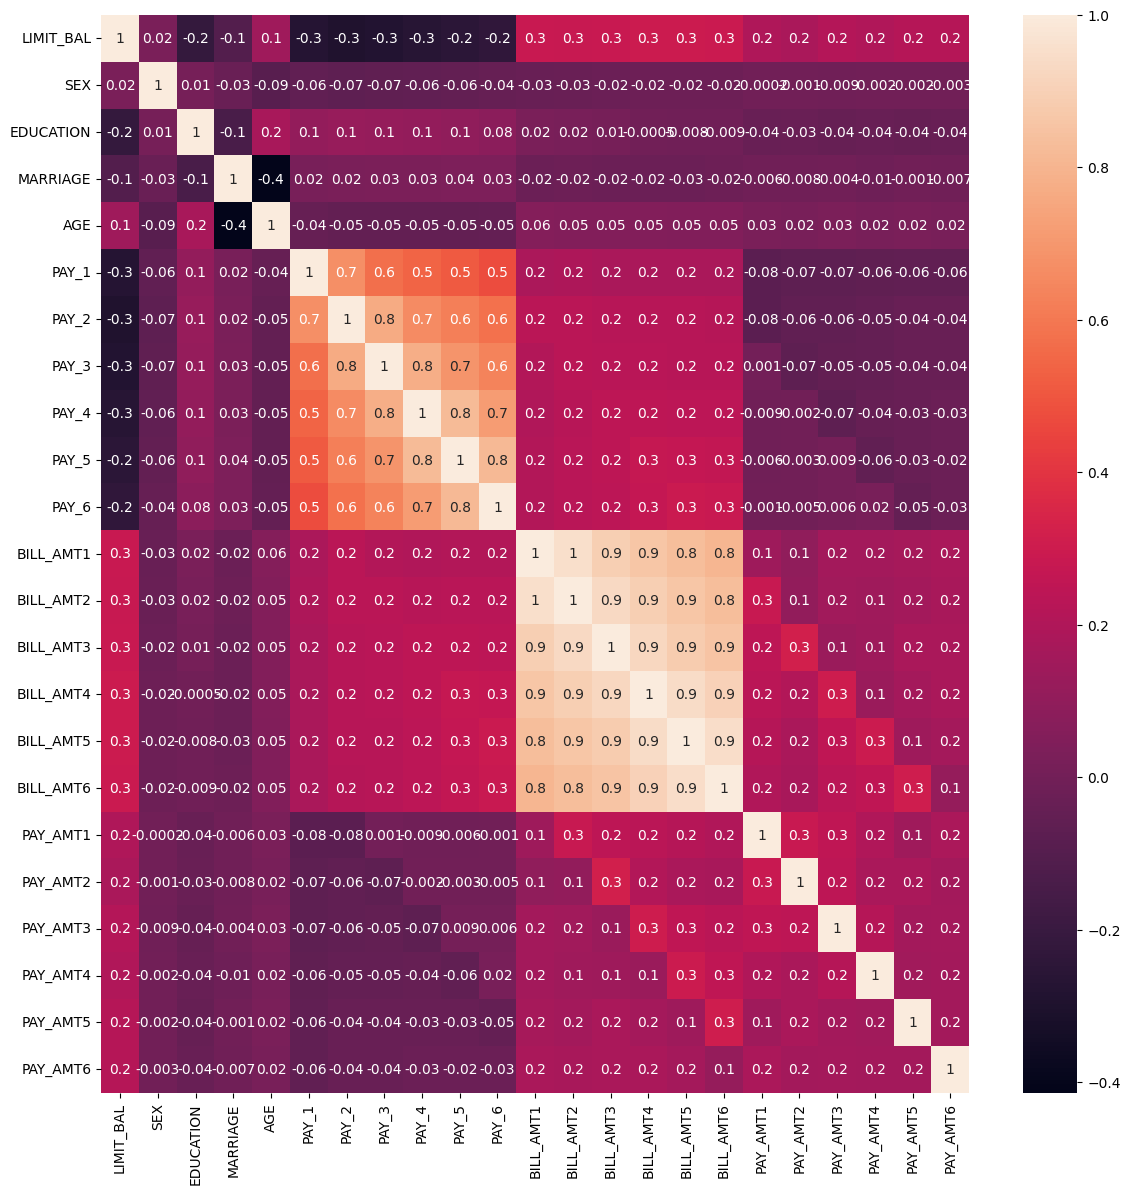

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

corr = X_features.corr()
plt.figure(figsize=(14, 14))
sns.heatmap(corr, annot=True, fmt='.1g')

- BILL_AMT1~BILL_AMT6 속성들은 서로 상관도가 0.9 이상으로 매우 높아 비슷한 정보를 담고 있음.
- 이처럼 상관관계가 높은 변수들은 소수의 PCA 컴포넌트만으로도 전체 변동성을 효과적으로 설명할 수 있음.
- 따라서 해당 6개 속성을 2개의 PCA 컴포넌트로 변환한 뒤 explained_variance_ratio_로 변동성 비율을 확인함.

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# BILL_AMT1 ~ BILL_AMT6까지 6개의 속성명 생성
cols_bill = ['BILL_AMT'+str(i) for i in range(1,7)]
print('대상 속성명:', cols_bill)

# 2개의 PCA 속성을 가진 PCA 객체 생성하고, explained_variance_ratio_ 계산을 위해 fit() 호출
scaler = StandardScaler()
df_cols_scaled = scaler.fit_transform(X_features[cols_bill])
pca = PCA(n_components=2)
pca.fit(df_cols_scaled)
print('PCA Component별 변동성:', pca.explained_variance_ratio_)

대상 속성명: ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
PCA Component별 변동성: [0.90555253 0.0509867 ]


In [15]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rcf = RandomForestClassifier(n_estimators=300, random_state=156)
scores = cross_val_score(rcf, X_features, y_target, scoring='accuracy', cv=3)

print('CV=3인 경우의 개별 Fold세트별 정확도:', scores)
print('평균 정확도:{0:.4f}'.format(np.mean(scores)))

CV=3인 경우의 개별 Fold세트별 정확도: [0.8083 0.8196 0.8232]
평균 정확도:0.8170


In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 원본 데이터 세트에 먼저 StandardScaler 적용
scaler = StandardScaler()
df_scaled = scaler.fit_transform(X_features)

# 6개의 컴포넌트를 가진 PCA 변환을 수행하고 cross_val_score()로 분류 예측 수행.
pca = PCA(n_components=6)
df_pca = pca.fit_transform(df_scaled)
scores_pca = cross_val_score(rcf, df_pca, y_target, scoring='accuracy', cv=3)

print('CV=3인 경우의 PCA 변환된 개별 Fold 세트별 정확도:', scores_pca)
print('PCA 변환 데이터 세트 평균 정확도:{0:.4f}'.format(np.mean(scores_pca)))

CV=3인 경우의 PCA 변환된 개별 Fold 세트별 정확도: [0.7912 0.7974 0.802 ]
PCA 변환 데이터 세트 평균 정확도:0.7969


- 전체 23개 속성 중 6개의 PCA 컴포넌트만 사용했음에도 예측 성능 저하는 약 1~2% 정도에 그침.
- 이는 적은 수의 컴포넌트만으로도 원본 데이터의 중요한 정보를 효과적으로 유지할 수 있음을 보여줌.
- PCA는 데이터 시각화뿐 아니라 컴퓨터 비전 분야의 얼굴 인식(Eigen-face)에도 활발히 활용됨.

##6.3 LDA(Linear Discriminant Analysis)

###LDA 개요
- 선형 판별 분석법
- LDA는 PCA와 비슷한 차원 축소 기법이지만, 분류 성능 향상을 위해 클래스 구분을 최대한 유지하는 지도학습 기반 방법임.
- PCA가 데이터의 전체 변동성이 큰 축을 찾는다면, LDA는 클래스들을 가장 잘 분리할 수 있는 축을 찾음.
- 이를 위해 클래스 간 분산은 크게 하고, 클래스 내부 분산은 작게 만드는 방향으로 차원을 축소함.
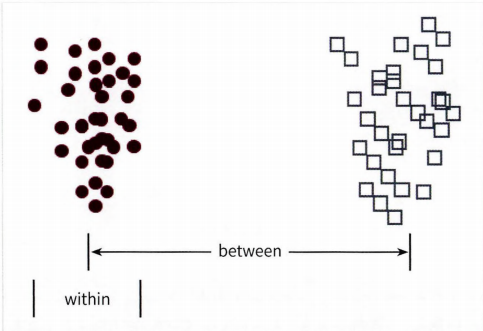

- LDA는 PCA와 비슷한 과정으로 차원을 축소하지만, 공분산 행렬 대신 클래스 간 분산과 클래스 내부 분산 행렬을 사용함.
- 먼저 클래스별 평균 벡터를 기반으로 두 분산 행렬을 계산한 뒤, 이를 고유벡터로 분해함.
- 이후 가장 큰 고유값에 해당하는 고유벡터를 선택해 데이터를 새로운 저차원 공간으로 변환함.
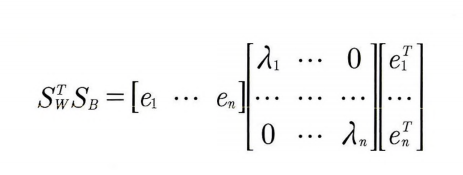

###붓꽃 데이터 세트에 LDA 적용하기

In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

iris = load_iris()
iris_scaled = StandardScaler().fit_transform(iris.data)

In [18]:
# 지도학습: 클래스의 결정값이 변환 시 필요함.
lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(iris_scaled, iris.target)
iris_lda = lda.transform(iris_scaled)
print(iris_lda.shape)

(150, 2)


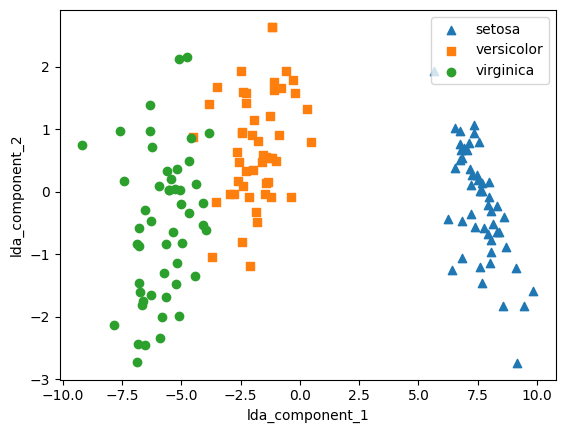

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

lda_columns = ['lda_component_1', 'lda_component_2']
irisDF_lda = pd.DataFrame(iris_lda, columns=lda_columns)
irisDF_lda['target']=iris.target

# setosa는 세모, versicolor는 네모, virginia는 동그라미로 표현
markers=['^', 's', 'o']

# setosa의 target 값은 0, versicolor는 1, virginica는 2. 각 target별로 다른 모양으로 산점도로 표시
for i, marker in enumerate(markers):
  x_axis_data = irisDF_lda[irisDF_lda['target']==i]['lda_component_1']
  y_axis_data = irisDF_lda[irisDF_lda['target']==i]['lda_component_2']

  plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])

plt.legend(loc='upper right')
plt.xlabel('lda_component_1')
plt.ylabel('lda_component_2')
plt.show()

##6.4 SVD(Singular Value Decomposition)

###SVD 개요
- SVD는 정방행렬뿐 아니라 행과 열의 크기가 다른 행렬에도 적용 가능한 행렬 분해 기법임.
- SVD는 행렬을 U, Σ, VT 세 행렬로 분해하며, 이때 특이벡터들은 서로 직교하는 성질을 가짐.
- 대각행렬 Σ의 대각 원소들은 특이값이며, 이는 원본 행렬의 중요한 정보를 나타냄.
- 일반적인 SVD에서는 불필요한 0 특이값과 관련된 부분을 제거해 더 작은 형태의 행렬로 압축함.
- 이렇게 차원을 줄인 형태를 컴팩트 SVD라 하며, 원본 데이터를 더 효율적으로 표현할 수 있음.
- Truncated SVD는 여기서 상위 몇 개의 중요한 특이값만 남겨 추가로 차원을 축소하는 방법임.
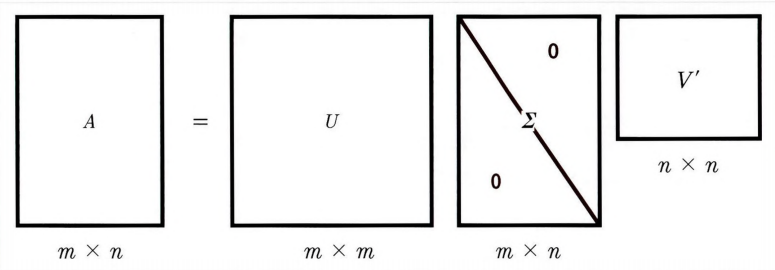

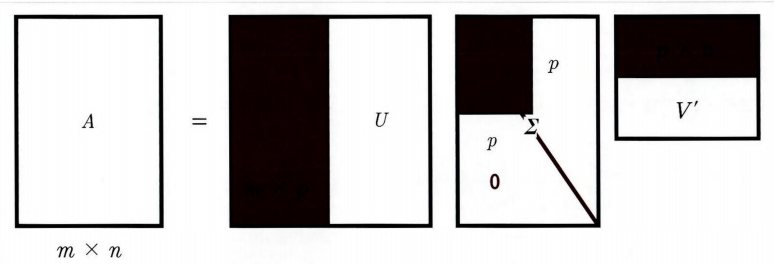

In [20]:
# 넘파이의 svd 모듈 임포트
import numpy as np
from numpy.linalg import svd

# 4x4 랜덤 행렬 a 생성 <- 개별 로우끼리의 의존성을 없애기 위함.
np.random.seed(121)
a = np.random.randn(4,4)
print(np.round(a,3))

[[-0.212 -0.285 -0.574 -0.44 ]
 [-0.33   1.184  1.615  0.367]
 [-0.014  0.63   1.71  -1.327]
 [ 0.402 -0.191  1.404 -1.969]]


In [21]:
U, Sigma, Vt = svd(a)
print(U.shape, Sigma.shape, Vt.shape)
print('U matrix:\n', np.round(U, 3))
print('Sigma Value:\n', np.round(Sigma, 3))
print('V transpose matrix:\n', np.round(Vt, 3))

(4, 4) (4,) (4, 4)
U matrix:
 [[-0.079 -0.318  0.867  0.376]
 [ 0.383  0.787  0.12   0.469]
 [ 0.656  0.022  0.357 -0.664]
 [ 0.645 -0.529 -0.328  0.444]]
Sigma Value:
 [3.423 2.023 0.463 0.079]
V transpose matrix:
 [[ 0.041  0.224  0.786 -0.574]
 [-0.2    0.562  0.37   0.712]
 [-0.778  0.395 -0.333 -0.357]
 [-0.593 -0.692  0.366  0.189]]


In [22]:
# Sigma를 다시 0을 포함한 대칭행렬로 변환
Sigma_mat = np.diag(Sigma)
a_ = np.dot(np.dot(U, Sigma_mat), Vt)
print(np.round(a_, 3))

[[-0.212 -0.285 -0.574 -0.44 ]
 [-0.33   1.184  1.615  0.367]
 [-0.014  0.63   1.71  -1.327]
 [ 0.402 -0.191  1.404 -1.969]]


In [23]:
a[2] = a[0] + a[1]
a[3] = a[0]
print(np.round(a,3))

[[-0.212 -0.285 -0.574 -0.44 ]
 [-0.33   1.184  1.615  0.367]
 [-0.542  0.899  1.041 -0.073]
 [-0.212 -0.285 -0.574 -0.44 ]]


In [24]:
# 다시 SVD를 수행해 Sigma 값 확인
U, Sigma, Vt = svd(a)
print(U.shape, Sigma.shape, Vt.shape)
print('Sigma Value:\n', np.round(Sigma, 3))

(4, 4) (4,) (4, 4)
Sigma Value:
 [2.663 0.807 0.    0.   ]


- 이전과 차원은 같지만 Sigma 값 중 2개가 0으로 변함.
- 선형 독립인 로우 벡터의 개수가 2개: 행렬의 Rank = 2

In [25]:
# U 행렬의 경우는 Sigma와 내적을 수행하므로 Sigma의 앞 2행에 대응되는 앞 2열만 추출
U_ = U[:, :2]
Sigma_ = np.diag(Sigma[:2])
# V 전치 행렬의 경우는 앞 2행만 추출
Vt_ = Vt[:2]
print(U_.shape, Sigma_.shape, Vt_.shape)
# U, Sigma, Vt의 내적을 수행하며, 다시 원본 행렬 복원
a_ = np.dot(np.dot(U_, Sigma_), Vt_)
print(np.round(a_, 3))

(4, 2) (2, 2) (2, 4)
[[-0.212 -0.285 -0.574 -0.44 ]
 [-0.33   1.184  1.615  0.367]
 [-0.542  0.899  1.041 -0.073]
 [-0.212 -0.285 -0.574 -0.44 ]]


- Truncated SVD는 전체 특이값 중 중요한 일부만 사용해 행렬을 더 작은 차원으로 분해하는 방법임.
- 이 과정에서 원본 데이터를 완벽히 복원할 수는 없지만, 중요한 정보는 유지한 채 원본 행렬을 근사할 수 있음.
- 사이파이의 svds를 사용하면 Truncated SVD를 수행할 수 있으며, 복원된 행렬과 원본 행렬을 비교해 성능을 확인할 수 있음.

In [27]:
import numpy as np
from scipy.sparse.linalg import svds
from scipy.linalg import svd

# 원본 행렬을 출력하고 SVD를 적용할 경우 U, Sigma, Vt의 차원 확인
np.random.seed(121)
matrix = np.random.random((6,6))
print('원본 행렬:\n', matrix)
U, Sigma, Vt = svd(matrix, full_matrices=False)
print('\n분해  행렬 차원:', U.shape, Sigma.shape, Vt.shape)
print('\nSigma값 행렬:', Sigma)

# Truncated SVD로 Sigma 행렬의 특이값을 4개로 하여 Truncated SVD 수행.
num_components = 4
U_tr, Sigma_tr, Vt_tr = svds(matrix, k=num_components)
print('\nTruncated SVD 분해 행렬 차원:', U_tr.shape, Sigma_tr.shape, Vt_tr.shape)
print('\nTruncated SVD Sigma값 행렬:', Sigma_tr)
matrix_tr = np.dot(np.dot(U_tr, np.diag(Sigma_tr)), Vt_tr) #output of TruncatedSVD

print('\nTruncated SVD로 분해 후 복원 행렬:\n', matrix_tr)

원본 행렬:
 [[0.11133083 0.21076757 0.23296249 0.15194456 0.83017814 0.40791941]
 [0.5557906  0.74552394 0.24849976 0.9686594  0.95268418 0.48984885]
 [0.01829731 0.85760612 0.40493829 0.62247394 0.29537149 0.92958852]
 [0.4056155  0.56730065 0.24575605 0.22573721 0.03827786 0.58098021]
 [0.82925331 0.77326256 0.94693849 0.73632338 0.67328275 0.74517176]
 [0.51161442 0.46920965 0.6439515  0.82081228 0.14548493 0.01806415]]

분해  행렬 차원: (6, 6) (6,) (6, 6)

Sigma값 행렬: [3.2535007  0.88116505 0.83865238 0.55463089 0.35834824 0.0349925 ]

Truncated SVD 분해 행렬 차원: (6, 4) (4,) (4, 6)

Truncated SVD Sigma값 행렬: [0.55463089 0.83865238 0.88116505 3.2535007 ]

Truncated SVD로 분해 후 복원 행렬:
 [[0.19222941 0.21792946 0.15951023 0.14084013 0.81641405 0.42533093]
 [0.44874275 0.72204422 0.34594106 0.99148577 0.96866325 0.4754868 ]
 [0.12656662 0.88860729 0.30625735 0.59517439 0.28036734 0.93961948]
 [0.23989012 0.51026588 0.39697353 0.27308905 0.05971563 0.57156395]
 [0.83806144 0.78847467 0.93868685 0.72673231

- 6x6 행렬을 SVD 분해하면 U, Sigma, Vt가 각각 (6, 6) (6,) (6, 6) 차원이지만, Truncated SVD의 n_components를 4로 설정해 U, Sigma, Vt를 (6, 4) (4,) (4, 6)로 각각 분해함.
- Truncated SVD로 분해된 행렬로 다시 복원할 경우 완벽하게 복원되지 않고 근사적으로 복원됨을 알 수 있음.

###사이킷런 TruncatedSVD 클래스를 이용한 변환
- TruncatedSVD 클래스는 U, Σ, Vᵀ 행렬을 직접 반환하지 않고 fit()과 transform()으로 차원 축소를 수행함.
- 상위 K개의 주요 컴포넌트(특이값) 만 사용하여 데이터를 저차원 공간으로 변환함.
- 변환된 데이터는 분해된 U×Σ 행렬을 기반으로 선형 변환하여 생성함.

Text(0, 0.5, 'TruncatedSVD Component 2')

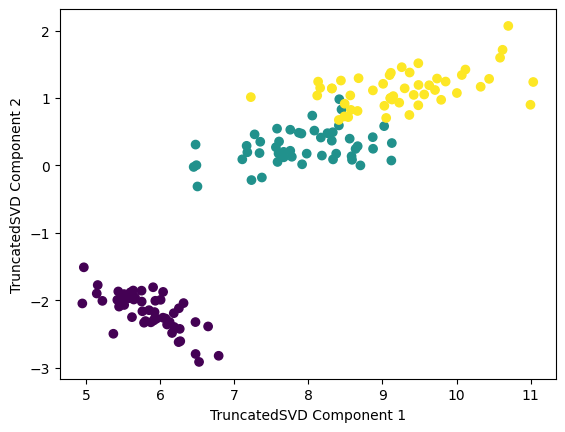

In [28]:
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
%matplotlib inline

iris = load_iris()
iris_ftrs = iris.data
# 2개의 주요 컴포넌트로 TruncatedSVD 변환
tsvd = TruncatedSVD(n_components=2)
tsvd.fit(iris_ftrs)
iris_tsvd = tsvd.transform(iris_ftrs)

# 산점도 2차원으로 TruncatedSVD 변환된 데이터 표현. 품종은 색깔로 구분
plt.scatter(x=iris_tsvd[:,0], y=iris_tsvd[:,1], c=iris.target)
plt.xlabel('TruncatedSVD Component 1')
plt.ylabel('TruncatedSVD Component 2')

- TruncatedSVD 변환 역시 PCA와 유사하게 변화나 후에 품종별로 어느 정도 클러스터링이 가능할 정도로 각 변환 속성으로 뛰어난 고유성을 가지고 있음.

Text(0.5, 1.0, 'PCA Transformed')

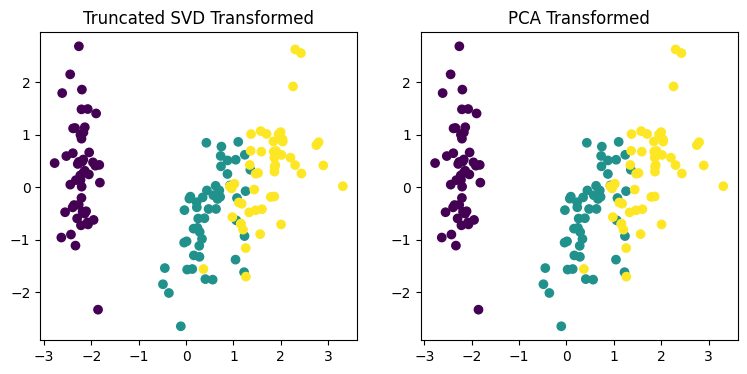

In [30]:
from sklearn.preprocessing import StandardScaler

# 붓꽃 데이터를 StandardScaler로 변환
scaler = StandardScaler()
iris_scaled = scaler.fit_transform(iris_ftrs)

# 스케일링된 데이터를 기반으로 TruncatedSVD 변환 수행
tsvd = TruncatedSVD(n_components=2)
tsvd.fit(iris_scaled)
iris_tsvd = tsvd.transform(iris_scaled)

# 스케일링된 데이터를 기반으로 PCA 변환 수행
pca = PCA(n_components=2)
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)

# TruncatedSVD 변환 데이터를 왼쪽에, PCA 변환 데이터를 오른쪽에 표현
fig, (ax1, ax2) = plt.subplots(figsize=(9,4), ncols=2)
ax1.scatter(x=iris_tsvd[:,0], y=iris_tsvd[:,1], c=iris.target)
ax2.scatter(x=iris_pca[:,0], y=iris_pca[:,1], c=iris.target)
ax1.set_title('Truncated SVD Transformed')
ax2.set_title('PCA Transformed')

- 두 개의 변환 행렬 값과 원본 속성별 컴포넌트 비율값을 실제로 서로 비교해 보면 거의 같음을 알 수 있음.

In [31]:
print((iris_pca - iris_tsvd).mean())
print((pca.components_ - tsvd.components_).mean())

2.351238416927378e-15
-4.85722573273506e-17


- 데이터가 스케일링되어 중심이 동일해지면 SVD와 PCA는 거의 동일한 변환 결과를 보임.
- 이는 PCA가 SVD 알고리즘을 기반으로 구현되었음을 의미함.
- SVD는 희소 행렬도 처리할 수 있으며, 이미지 압축, 패턴 인식, 신호 처리, 텍스트의 토픽 모델링 기법인 LSA 등의 분야에 활용됨.

##6.5 NMF(Non-Negative Matrix Factorization)

###NMF 개요
- NMF는 원소가 모두 0 이상인 행렬을 두 개의 양수 행렬(W, H)로 분해하여 원본 행렬을 근사하는 기법임.
- 행렬 분해를 통해 원본 데이터를 더 작은 차원의 잠재 요인(latent factor)으로 표현할 수 있음.
- W는 각 데이터가 잠재 요인을 얼마나 가지는지 나타내고, H는 잠재 요인이 원본 특성들과 어떻게 연결되는지를 나타냄.
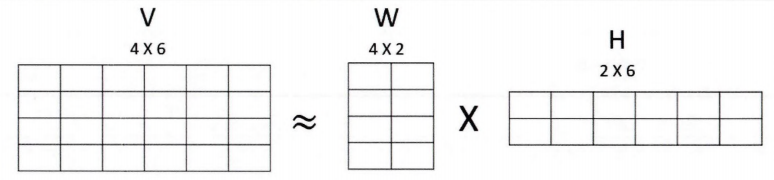
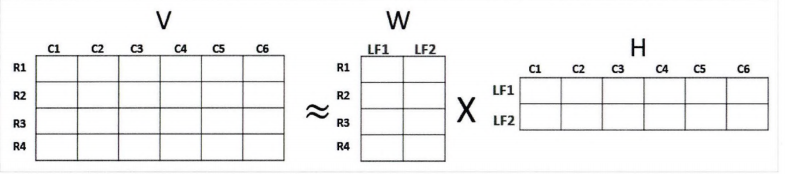

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Text(0, 0.5, 'NMF Component 2')

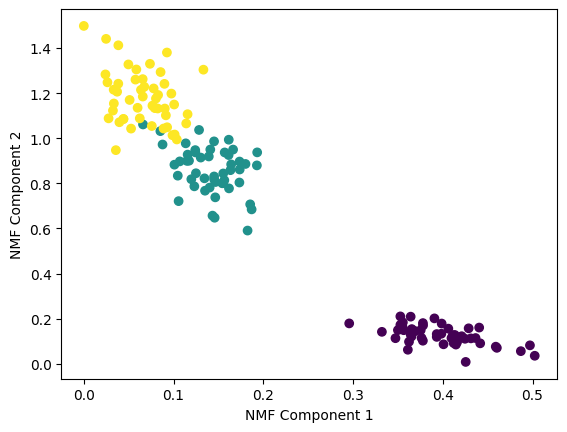

In [32]:
from sklearn.decomposition import NMF
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
%matplotlib inline

iris = load_iris()
iris_ftrs = iris.data
nmf = NMF(n_components=2)
nmf.fit(iris_ftrs)
iris_nmf = nmf.transform(iris_ftrs)
plt.scatter(x=iris_nmf[:,0], y=iris_nmf[:,1], c=iris.target)
plt.xlabel('NMF Component 1')
plt.ylabel('NMF Component 2')

- NMF는 이미지 압축, 패턴 인식, 텍스트 토픽 모델링, 문서 유사도 분석 및 클러스터링에 활용됨.
- 추천 시스템에서는 사용자-상품 평가 행렬을 분해하여 숨겨진 잠재 요인을 추출함.
- 추출된 잠재 요인을 바탕으로 미평가 상품의 평점을 예측하고, 높은 평점이 예상되는 상품을 추천함.

##6.6 정리
- 차원 축소는 피처 수를 줄이는 것뿐 아니라 데이터를 잘 설명하는 잠재 요인을 추출하는 데 의미가 있음.
- PCA는 데이터의 분산이 큰 방향을, LDA는 클래스 구분이 잘되는 방향을 찾아 차원을 축소함.
- SVD와 NMF는 고차원 행렬을 저차원 행렬로 분해하여 잠재 요인을 추출하며, 토픽 모델링과 추천 시스템 등에 활용됨.